In [1]:
from qsopt import * 
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import jax
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")

JAX version: 0.4.35
QuTiP version: 5.2.2


## Define experimental parameters

In [2]:
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 1

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = inverse_pulse_width      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, -4.0, 0.0, 4.0, 8.0])/inverse_pulse_width) 
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.0100,  
    dephasing = 0.0100,      
    relaxation = 0.0100
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [7.5]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   None
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      5
  Measurement times:    [-8.0, -4.0, 0.0, 4.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.01]
  Dephasing rate:       [0.01]
  Relaxation rate:      [0.01]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


C:\Users\User\AppData\Local\Temp\ipykernel_29600\2894009835.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


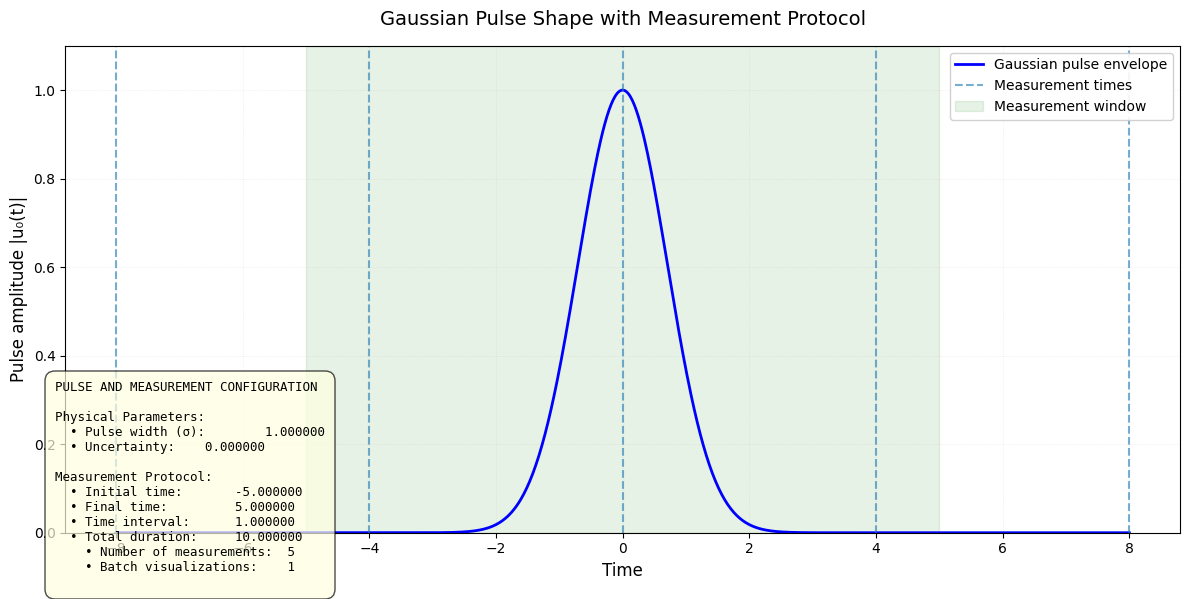

In [3]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=1
)
fig.show()

## Define quantum circuits

The new interface uses `QuantumCircuit` objects to define the gates applied before and after evolution. 

For the default RY protocol, we can simply use `None` (will auto-create RY circuits) or explicitly create them:

In [4]:
from qsopt.core.circuit import create_ry_circuit
initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])#, trainable=False)
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Initial circuit parameters: [Array(1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=1.5708)
Final circuit parameters: [Array(-1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=-1.5708)


## Define experiment

In [5]:
detection_metric = DetectionMetric(n_qubits=1, detection_criterion = 'any excited')

print(detection_metric)

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric
)


DetectionMetric: any excited with contrast
detection criterion:
  'any excited'
metric:
  'contrast'
batching logic:
  'average batching'
multiple measurement logic:
  'std probability aggregation'



## Test Single Simulation

In [6]:
results = experiment.run_simulation(debug=True)
print(results)


Debug times for each step:
initialize_solvers               :  0.912111
get_measurements                 :  0.000024
get_circuits                     :  0.288530
start_measurement_loop           :  0.000006
start_simulation_with0           :  0.000004
load_cached_parameters0          :  0.000013
start_simulation0                :  0.000170
measurement0:solver_0            :  2.100895
measurement0:measure_0           :  0.083921
measurement1:solver_0            :  0.043468
measurement1:measure_0           :  0.017808
measurement2:solver_0            :  0.030456
measurement2:measure_0           :  0.000345
measurement3:solver_0            :  0.024230
measurement3:measure_0           :  0.000230
returning_simulation0            :  0.019608
start_simulation_no0             :  0.000005
load_cached_parameters0          :  0.000013
start_simulation0                :  0.000153
measurement0:solver_0            :  0.924036
measurement0:measure_0           :  0.000305
measurement1:solver_0      

## Time Evolution

TimeEvolutionResults:
  Time interval: [-8, 8]
  Number of time points: 300
  System type: Single-qubit
  Detection Criterion: any excited
  Probabilities: ['detection_probability']
  Pulse shape: Available
  Measurement times: [-8.0, -4.0, 0.0, 4.0, 8.0]
  Cavity population: Available
  Field population: Available


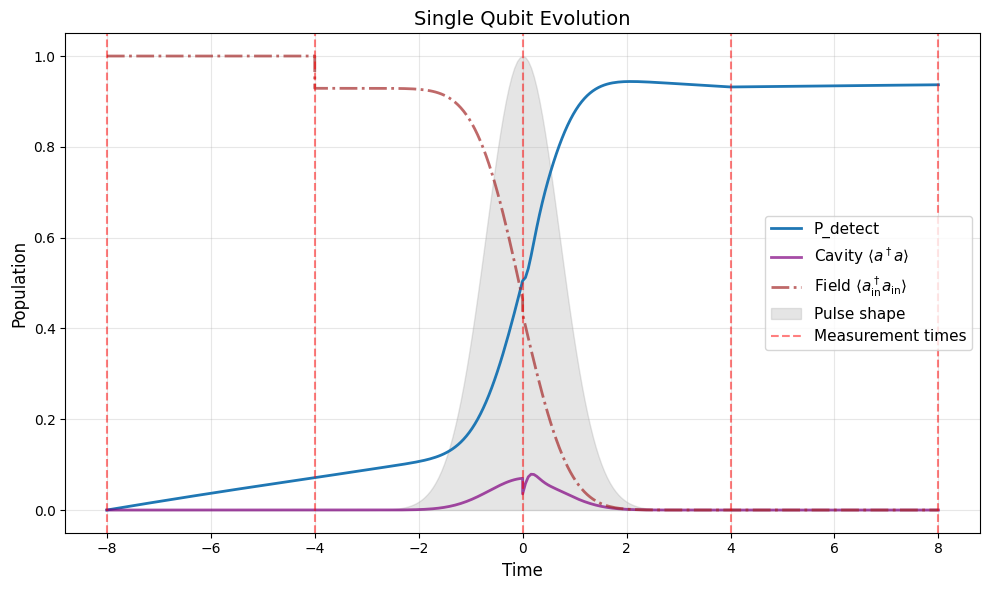

In [7]:
result = experiment.time_evolution(n_points=300, with_interaction=True)
print(result)

from qsopt.utils.visualization import plot_time_evolution
plot_time_evolution(
    evolution_data=result,
    show_pulse=True,
    show_measurements=True,
    show_cavity_population=True,  # Cavity population (purple)
    show_field_population=True,   # External field population (brown)
    title='Single Qubit Evolution',
    figsize=(10, 6)
)
plt.show()

## Run Optimization

In [ ]:
import optax

# The experiment automatically uses its built-in callback (saves every epoch by default)
history = experiment.optimize_rotations(
    initial_values=[1.3, -1.0], 
    num_steps=250,
    verbose=True,
    verbose_step=20,
    batch_size=1,
    tolerance=1e-7,
    optimizer=optax.sgd(learning_rate=0.01)
)

Configuration:
    Max iterations: 250
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric: any excited with contrast
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.300  rad (74.5°)
        param1.  reset_RY[0]  = -1.000 rad (-57.3°)
Step  setup0_RY[0]   reset0_RY[0]   Contrast    Grad Norm   Time
---------------------------------------------------------------------
0     1.300000       -1.000000      0.544372    5.42e-01    00h00m26s
20    1.289124       -1.095056      0.590206    4.15e-01    00h00m33s


In [ ]:
print(history)

MODE: Optimization
     Total iterations: 250
     Best epoch:        250
     Converged: False
     Final gradient norm: 7.380013e-02
  Best Parameters:
     Initial circuit:
        param_0: 1.460882 rad (83.70°)
     Final circuit:
        param_0: -1.444654 rad (-82.77°)
  Detection Probabilities:
     P(with photon):    0.924472
     P(without photon): 0.246678
     Contrast:          0.677795


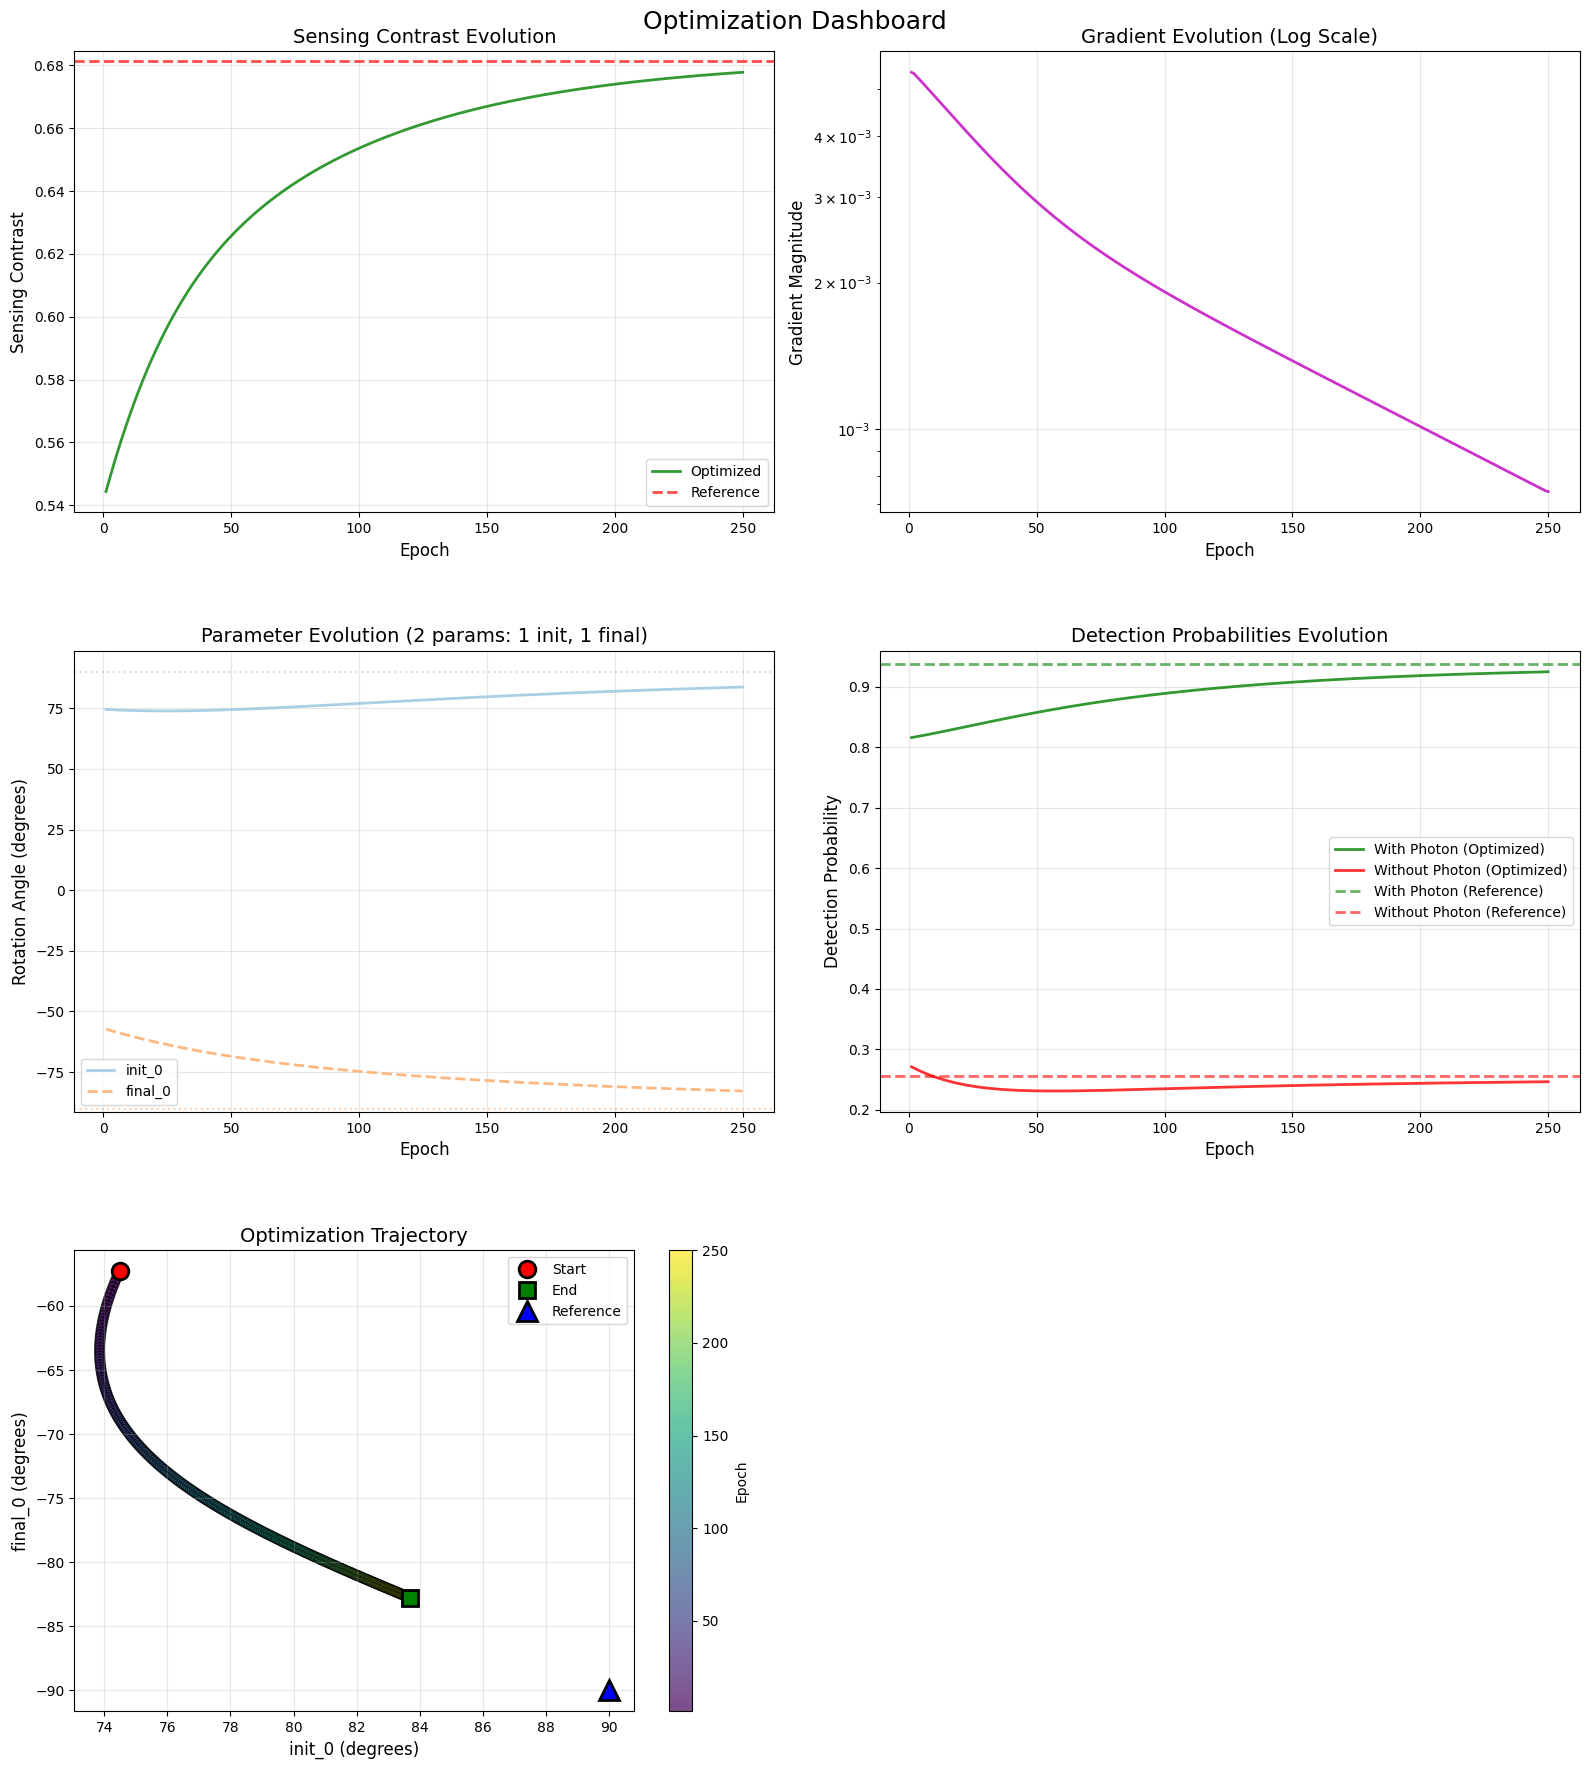

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_probabilities=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [ ]:
time_callback = experiment.optimize_measurement_times(batch_size=1, mode='discrete', verbose=True)

Computing time interval landscape (mode: discrete)...
  Circuit parameters: θ_init=83.7°, θ_final=-82.8°
  Resolution: 50 points
  Batch size: 1 realizations
  Total evolution time: 10.0000
  Progress: 100.0% (interval=10.0000, n_meas=2, contrast=0.672050)
Completed in 28.0s (0.560s per point)
  Optimal interval: 1.0000 (n_meas=11, contrast=0.791360)

Optimization complete:
  Best interval: 1.0000
  Best contrast: 0.791360
  Number of measurements: 11


Time interval landscape plot saved to: results/time_interval_opt.pdf


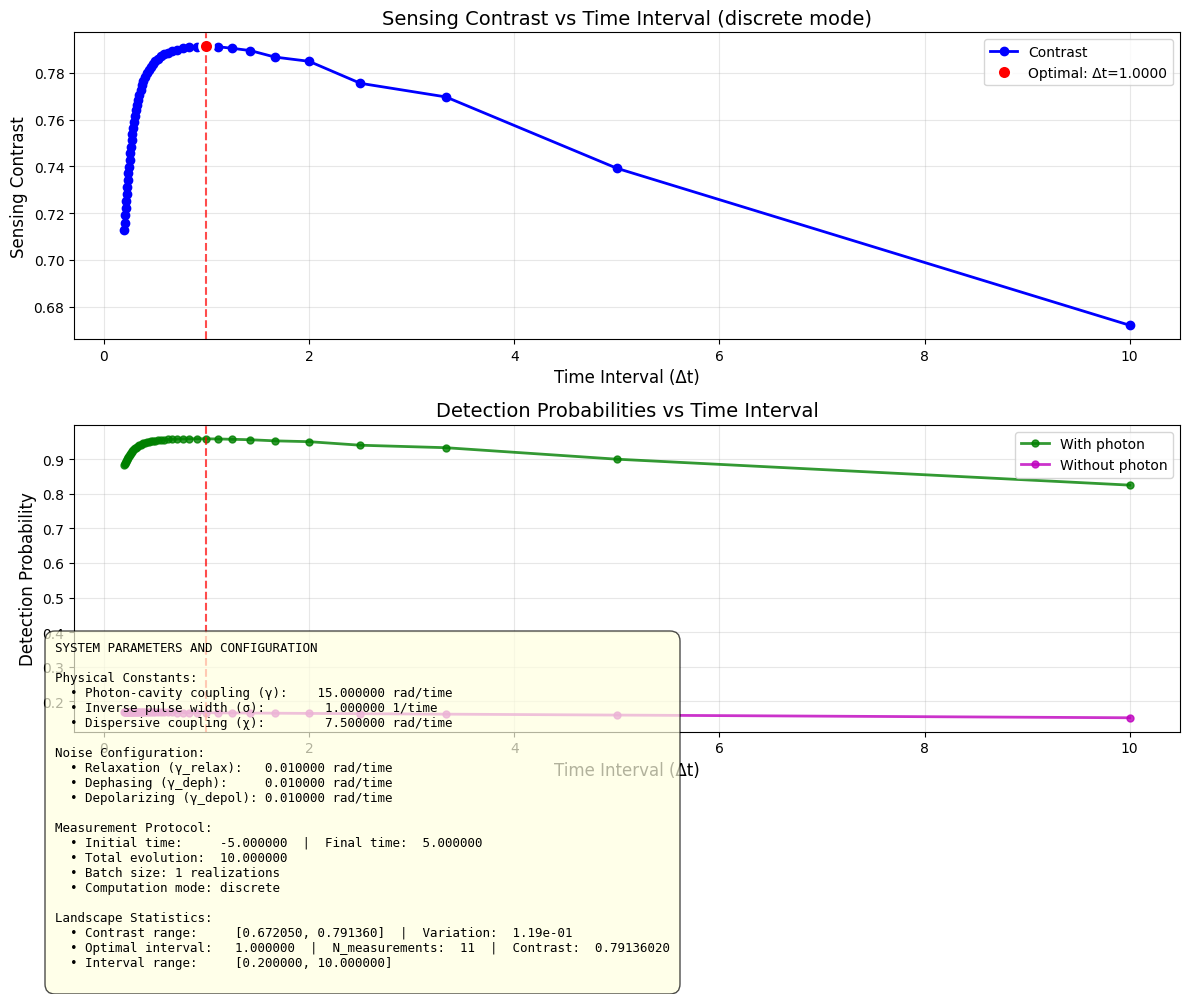

In [ ]:
from qsopt.utils.visualization import plot_time_interval_landscape

fig = plot_time_interval_landscape(
    landscape_data=time_callback,
    exp_params=experiment.experimental_params,
    save_path='results/time_interval_opt.pdf'
)


## Sweep chi-gamma

In [ ]:
results_sweep = experiment.sweep_chi_gamma(
    chi_interval=[1.0, 30.0],
    gamma_interval=[1.0, 60.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [1.00, 30.00] (linear scale)
  γ range: [1.00, 60.00] (linear scale)
  Progress: 10.0% | Elapsed: 26.9s
  Progress: 20.0% | Elapsed: 52.4s
  Progress: 30.0% | Elapsed: 78.0s
  Progress: 40.0% | Elapsed: 104.9s
  Progress: 50.0% | Elapsed: 132.4s
  Progress: 60.0% | Elapsed: 159.1s
  Progress: 70.0% | Elapsed: 184.7s
  Progress: 80.0% | Elapsed: 211.6s
  Progress: 90.0% | Elapsed: 240.3s
  Progress: 100.0% | Elapsed: 269.7s
Sweep completed in 269.7s
  Max contrast: 0.801548
  Optimal χ: 30.000
  Optimal γ: 60.000


SweepResults:
  Parameter 1: gamma
    Interval: [1, 60]
    Scale: linear
    Resolution: 10 points
  Parameter 2: chi
    Interval: [1, 30]
    Scale: linear
    Resolution: 10 points
  Available results: contrast_map, detection_map, detection_without_map
  Optimal point: chi=30, gamma=60


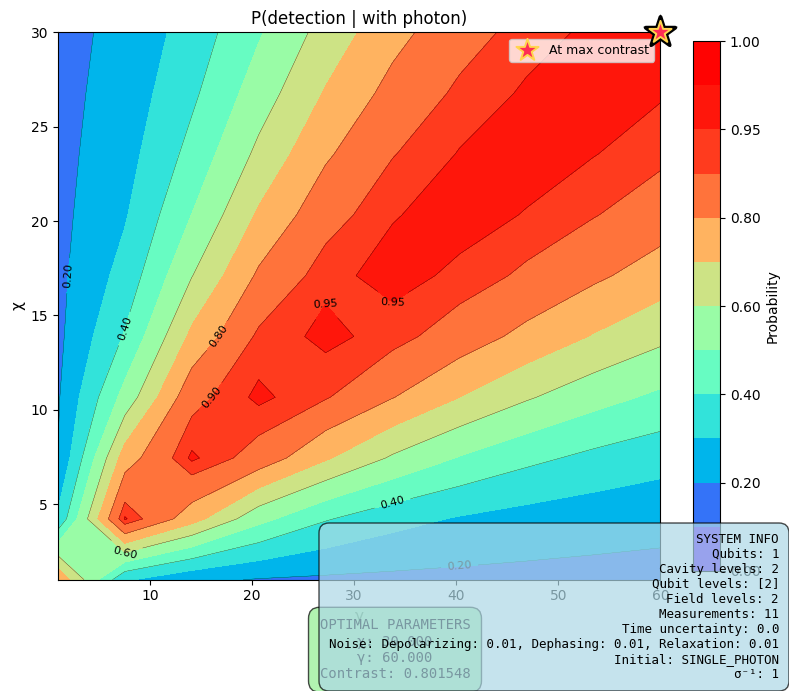

In [ ]:
from qsopt.utils.visualization import plot_sweep_results

print(results_sweep)

plot_sweep_results(
    results_sweep,
    results_to_plot=['detection_map'],
    figsize=(8, 7)
)
plt.show()